# BMR approximation vs direct HMI active-region insertion

The SHARPS-driven runs so far inject each active region as an **idealized
bipole** (`SHARPSource` / `make_bmr_yeates`): a smooth two-parameter fit to the
region's flux, separation and tilt. The SHARPS database also stores the **real**
`B_r` map of every region (`sharpNNNNN.nc`), so we can instead insert the
observed field directly (`SHARPPatchSource`).

This notebook (1) shows what the idealization discards, and (2) compares the
driven-run diagnostics — polar field, axial dipole, unsigned flux, butterfly —
between the two, against HMI. The question it answers: *does the internal
structure of active regions matter for the large-scale field evolution, or is
the bipole approximation sufficient?*

In [1]:
import sys, pathlib, os
try:
    import sft2d
except ModuleNotFoundError:
    sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import netcdf_file

from sft2d import (create_grid, meridional_flow, differential_rotation, evolve,
                   SHARPSource, SHARPPatchSource)
from sft2d.src.initial_conditions import initialize_field
from sft2d.src.sharp_driver import _read_catalogue
from sft2d.analysis.analysis import calculate_polar_field, calculate_dm, calculate_usflx
from sft2d.data import HMI_SYNOPTIC_FITS, load_hmi_polar_field
print("sft2d", sft2d.__version__)

sft2d 0.1.0


## Paths

`NC_DIR` is the SHARPS database directory (holding `bmrsharps_evol.txt` and the
`sharpNNNNN.nc` region maps). Override with the `SFT2D_SHARPS_DB` environment
variable.

In [2]:
NC_DIR = os.environ.get(
    "SFT2D_SHARPS_DB",
    "/Users/sdash/NSO/Work/GIT-Projects/sharps-bmrs-db/sharps-bmrs-db")
CATALOGUE = os.path.join(NC_DIR, "bmrsharps_evol.txt")
assert os.path.exists(CATALOGUE), CATALOGUE
cat = _read_catalogue(CATALOGUE)
print(f"{len(cat)} regions, {cat['date'].min().date()} -> {cat['date'].max().date()}")

2979 regions, 2010-07-06 -> 2026-06-22


## 1. What the idealization discards

Each `.nc` holds both `br` (the real HMI patch) and `br_bipole` (the database's
fitted bipole), on the same sin-latitude grid. Three representative regions: a
clean bipolar AR, a large multipolar complex, and an anti-Joy region.

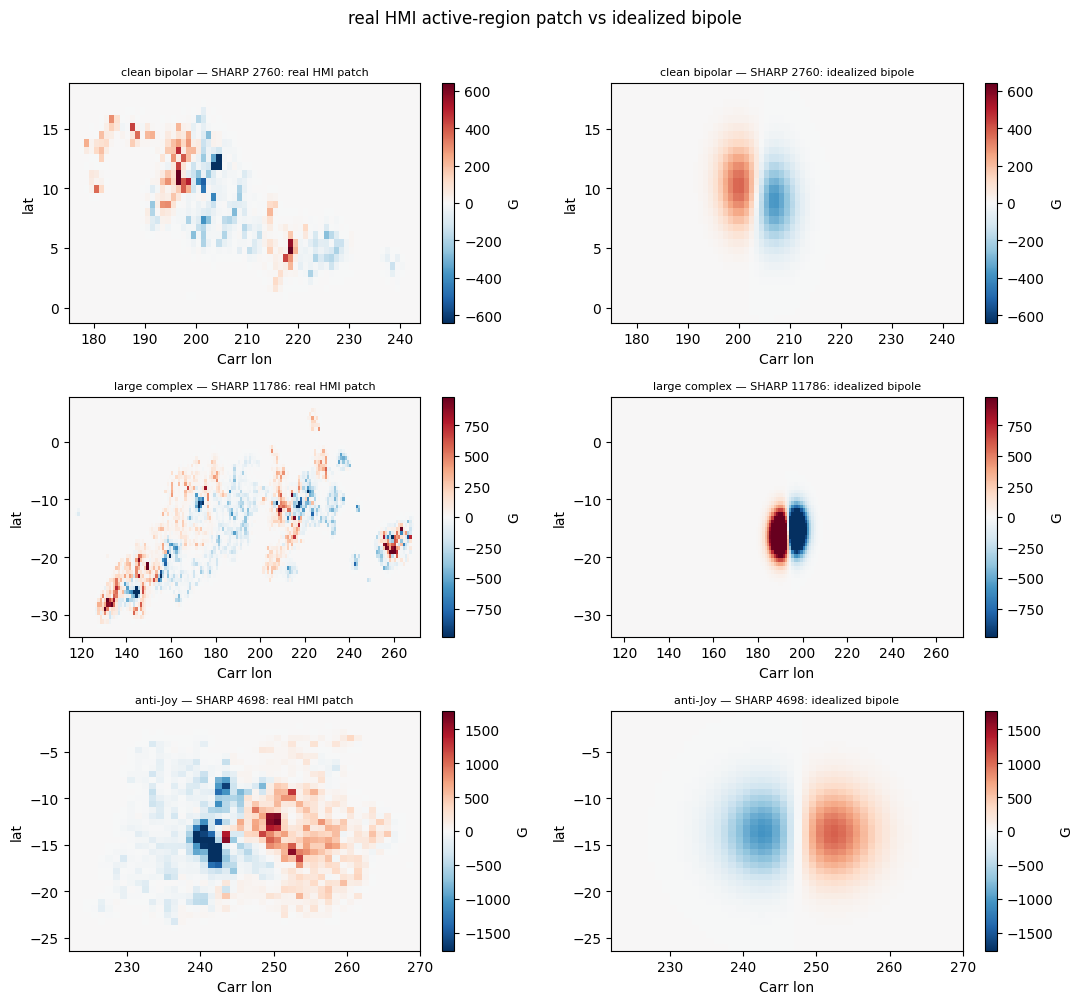

In [3]:
def load_nc(sid):
    fh = netcdf_file(os.path.join(NC_DIR, f"sharp{int(sid):05d}.nc"), "r", mmap=False)
    br = fh.variables["br"][:].copy(); bp = fh.variables["br_bipole"][:].copy(); fh.close()
    return br, bp

have = cat[cat["sharp"].apply(lambda s: os.path.exists(os.path.join(NC_DIR, f"sharp{int(s):05d}.nc")))]
def pick(mask): return int(have[mask].sort_values("flux").iloc[-1]["sharp"])
picks = [(pick((have.tilt.abs()<20)&(have.flux.between(1.5e22,4e22))), "clean bipolar"),
         (pick(have.flux>3e23), "large complex"),
         (pick(have.tilt.abs()>150), "anti-Joy")]
ns=180; s=np.linspace(-1+1/ns,1-1/ns,ns); lat=np.rad2deg(np.arcsin(s))
nph=360; lon=np.linspace(0.5,359.5,nph)

fig, ax = plt.subplots(len(picks),2,figsize=(11,3.3*len(picks)))
for i,(sid,lab) in enumerate(picks):
    br,bp=load_nc(sid); nz=np.abs(br)>0.5; si,pi=np.where(nz)
    la=slice(max(si.min()-3,0),si.max()+4); lo=slice(max(pi.min()-3,0),pi.max()+4)
    vmax=np.percentile(np.abs(br[nz]),99)
    for j,(M,t) in enumerate([(br,"real HMI patch"),(bp,"idealized bipole")]):
        a=ax[i,j]; pm=a.pcolormesh(lon[lo],lat[la],M[la,lo],cmap="RdBu_r",vmin=-vmax,vmax=vmax,shading="auto")
        a.set_title(f"{lab} — SHARP {sid}: {t}",fontsize=8); a.set_xlabel("Carr lon"); a.set_ylabel("lat")
        fig.colorbar(pm,ax=a,label="G")
fig.suptitle("real HMI active-region patch vs idealized bipole",y=1.01); fig.tight_layout()

## 1b. The same regions, as the model actually receives them

Section 1 compared the raw `.nc` maps. Here we insert those same three regions
through the two **drivers** — onto the 181×360 model grid, flux-normalised exactly
as a driven run would — so we compare like with like: `SHARPPatchSource` (the real
HMI `B_r`, interpolated) vs `SHARPSource` (`make_bmr_yeates`, the idealized
bipole). The patch driver clearly delivers the observed multipolar structure and
scatter; the bipole driver delivers a clean two-lobe fit of the same total flux.

**This is the difference that a synoptic snapshot of the _evolved_ field can no
longer show** (Section 2, and the note after it): once a region has been sheared
and diffused for days-to-weeks, both drivers' surface maps look alike — which is
precisely the physical result the diagnostics quantify.

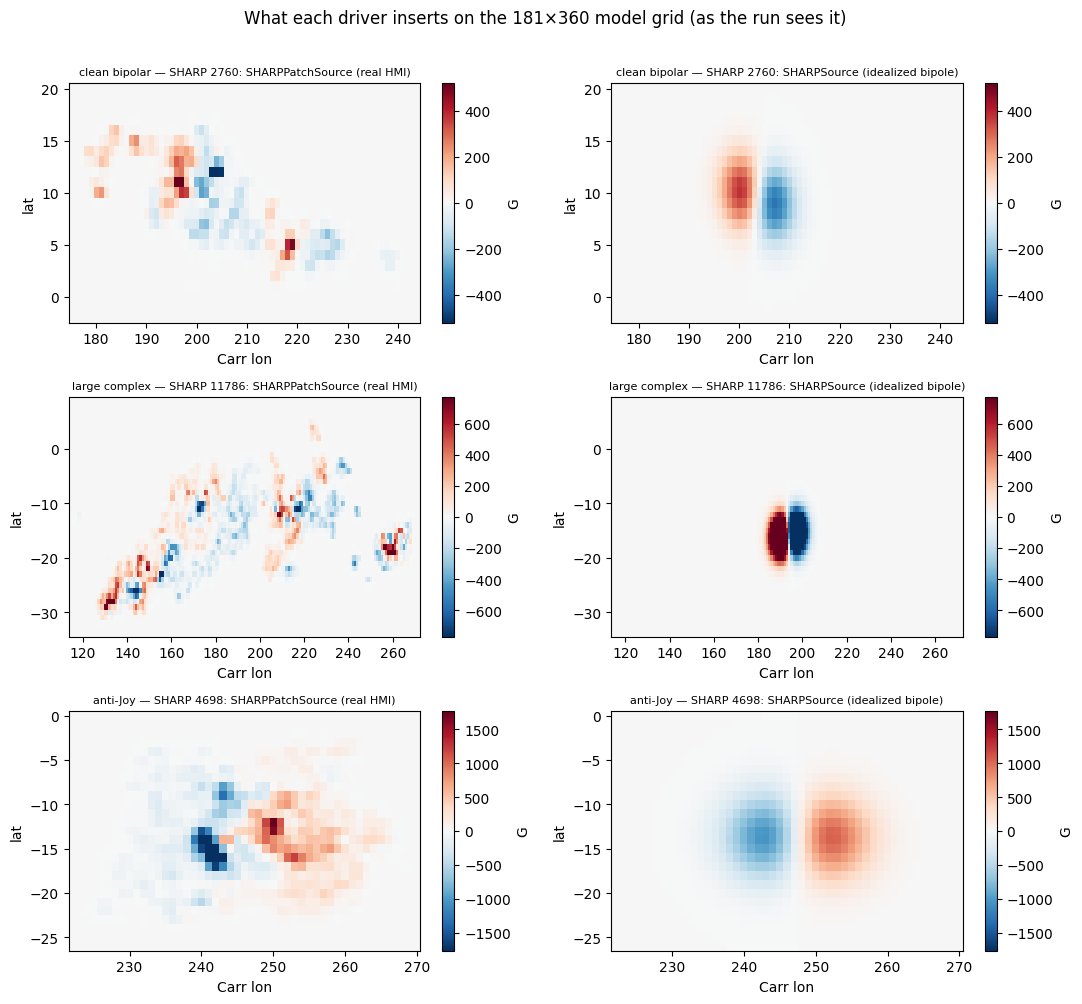

In [4]:
from sft2d import make_bmr_yeates

# Insert the same three regions through the two *drivers*, onto the model grid,
# exactly as a driven run would. This is the emergence field the model sees before
# any transport/diffusion — the difference a synoptic snapshot can no longer show.
g_ins = create_grid(181, 360)
lat_i = 90 - np.rad2deg(g_ins["colatitude"]); lon_i = np.rad2deg(g_ins["longitude"])
src_ins = SHARPPatchSource(CATALOGUE, nc_dir=NC_DIR, start_date="2010-05-01")

fig, ax = plt.subplots(len(picks), 2, figsize=(11, 3.3*len(picks)))
for i, (sid, lab) in enumerate(picks):
    row  = have[have.sharp.astype(int) == sid].iloc[0]
    flux = float(row.flux)
    real  = src_ins.patch_on_grid(sid, g_ins, flux)                                     # SHARPPatchSource
    ideal = make_bmr_yeates(g_ins, row.lat, row.lon, flux, sep_deg=row.sep, tilt_deg=row.tilt)  # SHARPSource
    nz = np.abs(real) > 1; li, pj = np.where(nz)
    la = slice(max(li.min()-3, 0), li.max()+4); lo = slice(max(pj.min()-3, 0), pj.max()+4)
    vmax = np.percentile(np.abs(real[nz]), 99)
    for j, (M, t) in enumerate([(real, "SHARPPatchSource (real HMI)"),
                                (ideal, "SHARPSource (idealized bipole)")]):
        a = ax[i, j]
        pm = a.pcolormesh(lon_i[lo], lat_i[la], M[la, lo], cmap="RdBu_r",
                          vmin=-vmax, vmax=vmax, shading="auto")
        a.set_title(f"{lab} — SHARP {sid}: {t}", fontsize=8)
        a.set_xlabel("Carr lon"); a.set_ylabel("lat"); fig.colorbar(pm, ax=a, label="G")
fig.suptitle("What each driver inserts on the 181×360 model grid (as the run sees it)", y=1.01)
fig.tight_layout()

## 2. Two driven runs, identical except the source

Same observed-map initial condition and 2010–2026 window; only the emergence
source differs — `SHARPSource` (idealized bipoles) vs `SHARPPatchSource` (real AR
maps). Both preserve each region's measured unsigned flux, so the comparison
isolates the flux *distribution* from the *amount*. This run uses the Yeates-2020
meridional flow (v₀ = 14 m/s), η = 350 km²/s and τ = 10 yr on a **181×360** grid,
and also stores 27-day `B_r` snapshots of the evolving surface for the synoptic
maps below. ~15 min.

In [5]:
import pandas as pd

wrote bmr_surface_fields_y20.npz  (49.7 MB, 219 maps)
bipole run: 788s



wrote patch_surface_fields_y20.npz  (49.8 MB, 219 maps)
patch run:  821s



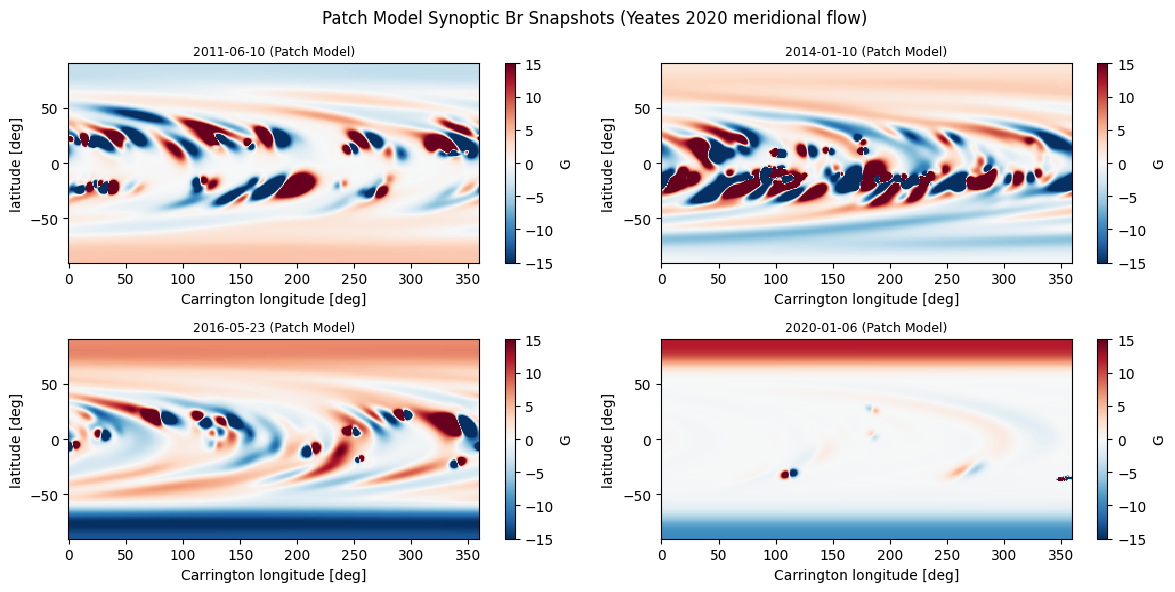

In [6]:
import time
grid = create_grid(181, 360)
mf = meridional_flow(grid, 14.0, profile="yeates2020") #yeates2020; schuessler-baumann
dr = differential_rotation(grid)
ETA, TAU = 3.5e8, 10*365.25*86400.0
CAP = 30.0
START, END = "2010-05-01", "2026-06-30"

def run(source, outfile):
    field = initialize_field(grid, "read", path=str(HMI_SYNOPTIC_FITS))
    yr, pn, ps, dip, usf, bfly = [], [], [], [], [], []
    
    # Snapshot variables
    SNAP_EVERY_DAYS = 27
    snap_br, snap_day = [], []

    class Rec:
        def record(self, d, B):
            if d % 10 == 0:
                yr.append(2010 + 0.33 + d/365.25)
                n, s = calculate_polar_field(B, grid, pol_cap_extent_deg=CAP)
                pn.append(n); ps.append(s); dip.append(calculate_dm(B, grid))
                usf.append(calculate_usflx(B, grid)); bfly.append(B.mean(axis=1).copy())
                
            # Full 2D surface-field snapshots
            if d % SNAP_EVERY_DAYS == 0:
                snap_br.append(B.copy()); snap_day.append(d)

    evolve(field, grid, mf, dr, ETA, source.num_days, source=source, tau_decay_s=TAU, recorder=Rec())
    
    # Process and save snapshots
    snap_br = np.array(snap_br)
    snap_date = pd.to_datetime(START) + pd.to_timedelta(snap_day, unit='D')
    snap_year = np.array([d.year + (d.dayofyear-1)/365.25 for d in snap_date])
    
    lat = np.rad2deg(np.pi/2 - grid['colatitude'])
    lon = np.rad2deg(grid['longitude'])

    np.savez_compressed(
        outfile,
        br=snap_br.astype(np.float32),                       
        date=np.array([str(d.date()) for d in snap_date]),   
        year=snap_year, lat=lat, lon=lon,
    )
    print(f"wrote {outfile}  "
          f"({pathlib.Path(outfile).stat().st_size/1e6:.1f} MB, {len(snap_br)} maps)")

    return dict(yr=np.array(yr), pn=np.array(pn), ps=np.array(ps), dip=np.array(dip),
                usf=np.array(usf), bfly=np.array(bfly).T)

# Execute both runs with different snapshot output files
t0 = time.time()
src_bmr = SHARPSource(CATALOGUE, start_date=START, end_date=END, flux_scale=1.0)
res_bmr = run(src_bmr, 'bmr_surface_fields_y20.npz')
print(f"bipole run: {time.time()-t0:.0f}s\n")

t0 = time.time()
src_patch = SHARPPatchSource(CATALOGUE, nc_dir=NC_DIR, start_date=START, end_date=END, flux_scale=1.0)
res_patch = run(src_patch, 'patch_surface_fields_y20.npz')
print(f"patch run:  {time.time()-t0:.0f}s\n")

# --- Helper functions and Plotting ---

def nearest_snapshot(date, path):
    """Return (br_map, date_str, lat, lon) of the saved snapshot nearest `date`."""
    z = np.load(path, allow_pickle=False)
    t = pd.Timestamp(date); ty = t.year + (t.dayofyear-1)/365.25
    i = int(np.argmin(np.abs(z['year'] - ty)))
    return z['br'][i], str(z['date'][i]), z['lat'], z['lon']

def show_synoptic(ax, br, lat, lon, title, bmax=15):
    pm = ax.pcolormesh(lon, lat, br, cmap='RdBu_r', vmin=-bmax, vmax=bmax, shading='auto')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Carrington longitude [deg]'); ax.set_ylabel('latitude [deg]')
    return pm

# Synoptic snapshots of the evolved (transported + diffused) surface field.
# NB: these are the *evolved* field, not the emergence field — every region has
# been sheared and diffused for days-to-weeks before it is sampled, so its raw
# HMI structure is gone in BOTH drivers (see Section 1b for the as-inserted maps).
picks = ['2011-06-01', '2014-01-01', '2016-06-01', '2020-01-01']
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for a, d in zip(axes.ravel(), picks):
    br, dd, la, lo = nearest_snapshot(d, path='patch_surface_fields_y20.npz')
    pm = show_synoptic(a, br, la, lo, f"{dd} (Patch Model)", bmax=15)
    fig.colorbar(pm, ax=a, label='G')
fig.suptitle('Patch Model Synoptic Br Snapshots (Yeates 2020 meridional flow)')
fig.tight_layout()
plt.show()

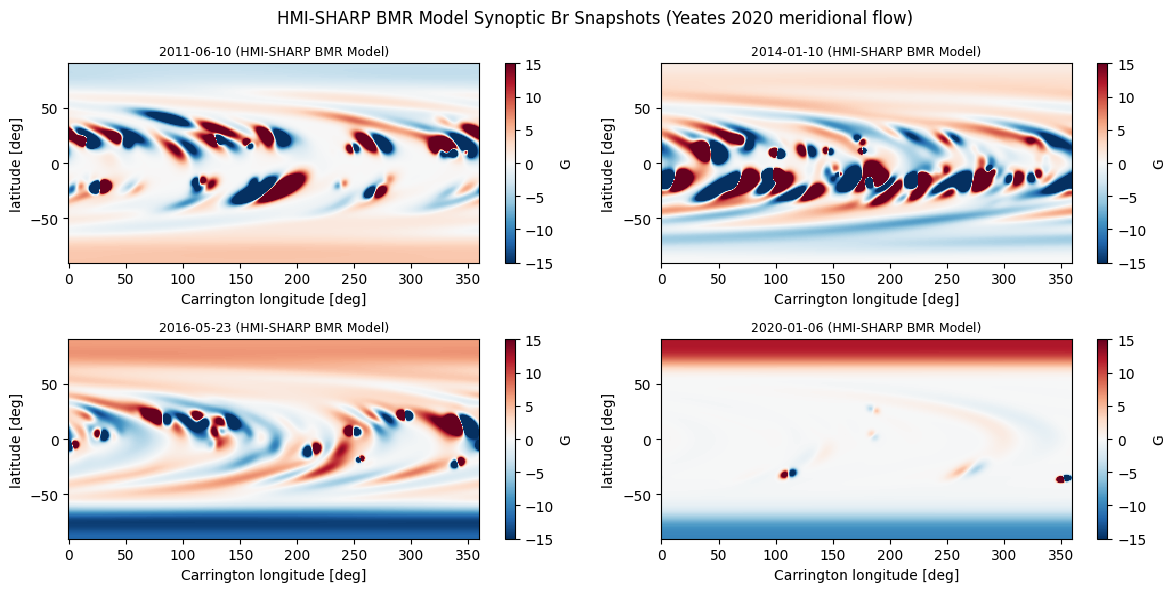

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for a, d in zip(axes.ravel(), picks):
    br, dd, la, lo = nearest_snapshot(d, path='bmr_surface_fields_y20.npz')
    pm = show_synoptic(a, br, la, lo, f"{dd} (HMI-SHARP BMR Model)", bmax=15)
    fig.colorbar(pm, ax=a, label='G')
fig.suptitle('HMI-SHARP BMR Model Synoptic Br Snapshots (Yeates 2020 meridional flow)')
fig.tight_layout()
plt.show()

### Why the two evolved snapshots look alike — and where they don't

The two synoptic maps above are the **evolved** surface field: by the time emerged
flux is sampled it has been sheared by differential rotation and spread by
supergranular diffusion for days-to-weeks, so a saturated (`|B|≤15 G`) synoptic
view of *either* driver shows the same smooth, blob-like active regions. That is
**not** the patch driver inserting idealized bipoles — Sections 1 and 1b show it
inserts the real HMI structure faithfully; it is diffusion erasing that structure
before the snapshot is taken, identically for both drivers.

That near-identity is itself the headline result: for the **large-scale** field the
bipole approximation reproduces the direct-patch run (Yeates 2020). The residual
`patch − bipole` map below isolates where the two genuinely differ.

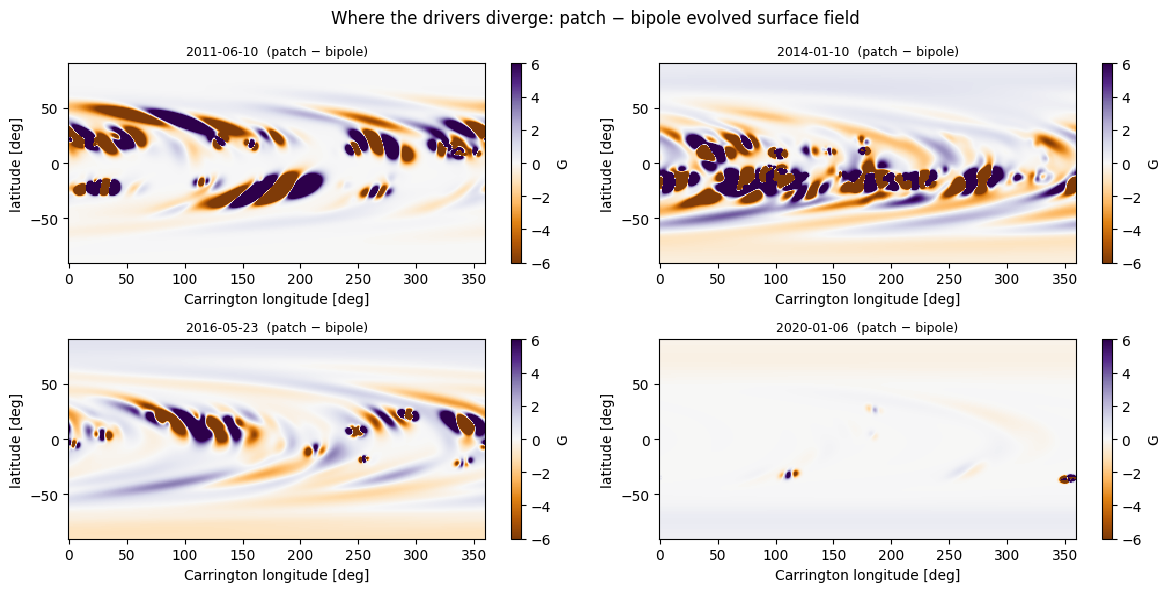

In [8]:
# Where the two drivers diverge: patch - bipole, same date, same evolved field.
# The difference concentrates at active latitudes (the AR belts) where the real
# internal structure and effective tilt depart from the fitted bipole; the
# large-scale poleward/polar field is nearly identical (the bipole approximation
# works for transport). This is the meaningful structural signal, not the
# saturated blobs above.
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for a, d in zip(axes.ravel(), picks):
    bp, dd, la, lo = nearest_snapshot(d, path='patch_surface_fields_y20.npz')
    bb, _,  _,  _  = nearest_snapshot(d, path='bmr_surface_fields_y20.npz')
    pm = a.pcolormesh(lo, la, bp - bb, cmap='PuOr', vmin=-6, vmax=6, shading='auto')
    a.set_title(f"{dd}  (patch − bipole)", fontsize=9)
    a.set_xlabel('Carrington longitude [deg]'); a.set_ylabel('latitude [deg]')
    fig.colorbar(pm, ax=a, label='G')
fig.suptitle('Where the drivers diverge: patch − bipole evolved surface field')
fig.tight_layout()
plt.show()

## 3. Polar field, axial dipole, unsigned flux — both drivers vs HMI

driver       peakD   corrN   corrS
bipole        3.17  +0.901  +0.856
patch         3.20  +0.857  +0.816


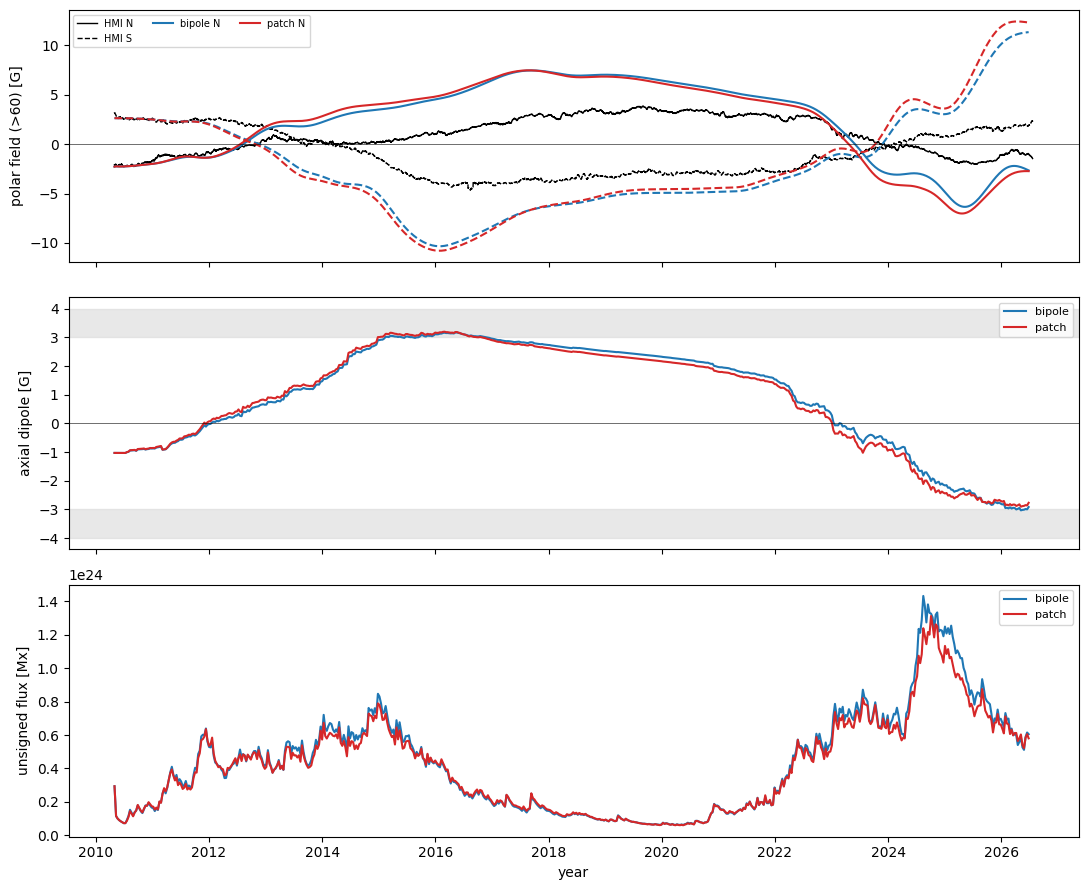

In [9]:
hmi = load_hmi_polar_field(); idx = hmi["mean_north"].index
hyr = idx.year + (idx.dayofyear-1)/365.25
mn, ms = hmi["mean_north"].values, hmi["mean_south"].values

def corr(a, b_yr, o):  # a: model, o: obs mean series on hyr
    oi = np.interp(b_yr, hyr, o); return np.corrcoef(a, oi)[0,1]
print(f"{'driver':10} {'peakD':>7} {'corrN':>7} {'corrS':>7}")
for lab, r in (("bipole", res_bmr), ("patch", res_patch)):
    print(f"{lab:10} {np.abs(r['dip']).max():7.2f} {corr(r['pn'],r['yr'],mn):+7.3f} {corr(r['ps'],r['yr'],ms):+7.3f}")

fig, ax = plt.subplots(3,1,figsize=(11,9),sharex=True)
ax[0].plot(hyr,mn,"k",lw=1,label="HMI N"); ax[0].plot(hyr,ms,"k--",lw=1,label="HMI S")
ax[0].plot(res_bmr["yr"],res_bmr["pn"],"C0",label="bipole N"); ax[0].plot(res_bmr["yr"],res_bmr["ps"],"C0--")
ax[0].plot(res_patch["yr"],res_patch["pn"],"C3",label="patch N"); ax[0].plot(res_patch["yr"],res_patch["ps"],"C3--")
ax[0].axhline(0,color="k",lw=0.4); ax[0].set_ylabel("polar field (>60) [G]"); ax[0].legend(ncol=3,fontsize=7)
ax[1].axhspan(3,4,color="0.85",alpha=0.6); ax[1].axhspan(-4,-3,color="0.85",alpha=0.6)
ax[1].plot(res_bmr["yr"],res_bmr["dip"],"C0",label="bipole"); ax[1].plot(res_patch["yr"],res_patch["dip"],"C3",label="patch")
ax[1].axhline(0,color="k",lw=0.4); ax[1].set_ylabel("axial dipole [G]"); ax[1].legend(fontsize=8)
ax[2].plot(res_bmr["yr"],res_bmr["usf"],"C0",label="bipole"); ax[2].plot(res_patch["yr"],res_patch["usf"],"C3",label="patch")
ax[2].set_ylabel("unsigned flux [Mx]"); ax[2].set_xlabel("year"); ax[2].legend(fontsize=8)
fig.tight_layout()

## 4. Butterfly diagrams side by side

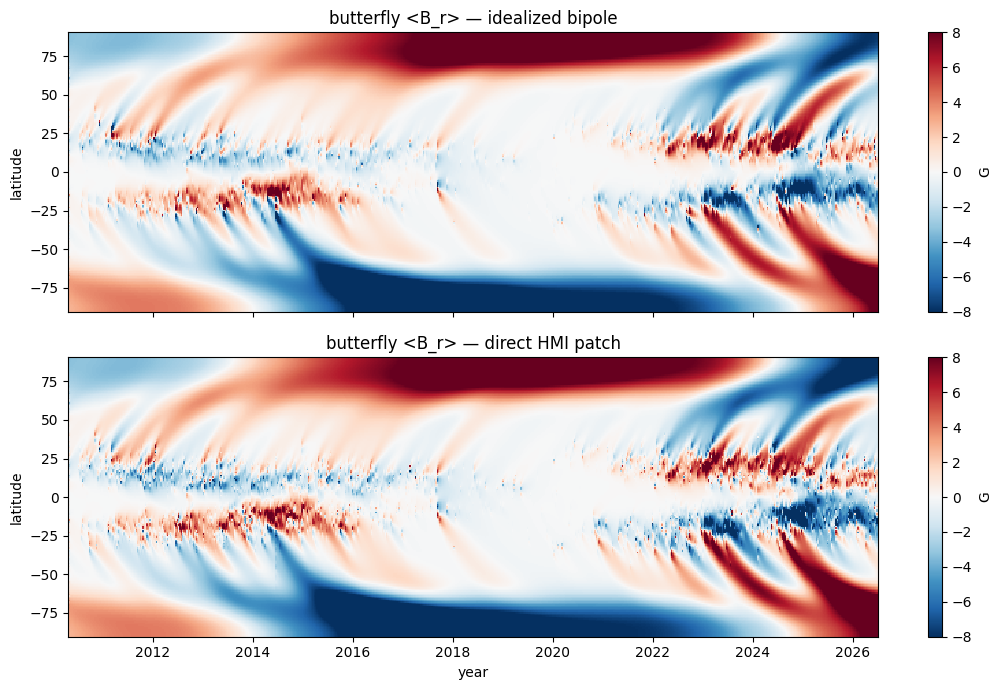

In [10]:
lat_g = np.rad2deg(np.pi/2 - grid["colatitude"])
fig, ax = plt.subplots(2,1,figsize=(11,7),sharex=True)
vmax = 8
for a,(lab,r) in zip(ax, (("idealized bipole",res_bmr),("direct HMI patch",res_patch))):
    pm=a.pcolormesh(r["yr"],lat_g,r["bfly"],cmap="RdBu_r",vmin=-vmax,vmax=vmax,shading="auto")
    a.set_ylabel("latitude"); a.set_title(f"butterfly <B_r> — {lab}"); fig.colorbar(pm,ax=a,label="G")
ax[1].set_xlabel("year"); fig.tight_layout()

## 5. Reading the comparison

Fill in from *your* run, but the questions:

* Do the **axial dipole** and its cycle-24 peak differ between the bipole and
  patch drivers? (They share the same total flux per region, so differences come
  from the flux *distribution* — how each region's structure and effective tilt
  project onto the axial dipole.)
* Does the **polar-field correlation** with HMI improve, worsen, or stay the same
  with the real patches?
* Is the **butterfly** more realistically textured with direct insertion, and
  does that change the poleward surges?
* The real patches carry the observed **hemispheric asymmetry** and multipolar
  tilt scatter that the idealization averages out — does that help the cycle-25
  south-hemisphere reversal timing that the bipole run got late?

Caveats: at 91×180 the SHARP maps (180×360) are interpolated onto a coarser grid,
so the finest AR structure is smoothed either way; run at 181×360 to reduce it.
Both drivers preserve each region's measured unsigned flux, so this isolates
*distribution* from *amount*.